In [71]:
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorly.decomposition import parafac
from tensorly import cp_to_tensor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error
from statsmodels.tsa.ar_model import AutoReg

In [72]:
PERIOD = 25
TRAIN_DAYS = 20
TEST_DAYS = 5
TIME = 52
FEATURES = 13
print(f"Tensor dimensions: {PERIOD} x {TIME} x {FEATURES}")

Tensor dimensions: 25 x 52 x 13


## 1. Data Collection & Preprocessing

In [73]:
df = pd.read_csv('cleaned_weekly_rainfall_data_1975_to_2016.csv')
df.head()

,year,week,Barisal,Bhola,Bogra,CoxsBazar,Dhaka,Faridpur,Ishurdi,Mymensingh,Rajshahi,Rangamati,Rangpur,Satkhira,Sylhet
0,1975,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0
1,1975,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1975,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1975,4,0.0,0.0,4.0,0.0,1.0,0.0,4.0,0.0,9.0,0.0,0.0,6.0,0.0
4,1975,5,0.0,0.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0


In [74]:
df.shape

(2192, 15)

In [75]:
2192//52

42

In [76]:
2016-1974

42

In [77]:
drop_cols = ['year', 'week']
df = df.drop(columns=drop_cols)

In [78]:
numeric_cols = df.select_dtypes(include='number').columns
df[numeric_cols] = df[numeric_cols].rolling(window=5, min_periods=1).mean()

data = df[numeric_cols][:PERIOD*TIME].values
tensor = data.reshape(PERIOD, TIME, FEATURES)

train_tensor = tensor[:TRAIN_DAYS, :, :]
test_tensor = tensor[TRAIN_DAYS:TRAIN_DAYS+TEST_DAYS, :, :]
print(f"Full tensor: {tensor.shape}")
print(f"Train tensor: {train_tensor.shape}")
print(f"Test tensor: {test_tensor.shape}")

Full tensor: (25, 52, 13)
Train tensor: (20, 52, 13)
Test tensor: (5, 52, 13)


## 2. Rank Sweep — Find Optimal Decomposition Rank

Sweep rank R from 1 to 10, measure reconstruction error for each.

In [79]:
max_rank = min(TRAIN_DAYS, TIME, FEATURES)
print(f"Max meaningful rank: {max_rank} (min of {TRAIN_DAYS}, {TIME}, {FEATURES})")

ranks = range(1, max_rank + 1)
reconstruction_errors = []
train_r2_scores = []

for R in ranks:
    try:
        weights, factors = parafac(train_tensor, rank=R, normalize_factors=True)
        reconstructed = cp_to_tensor((weights, factors))
        
        # Relative reconstruction error
        rel_error = np.linalg.norm(train_tensor - reconstructed) / np.linalg.norm(train_tensor)
        reconstruction_errors.append(rel_error)
        
        # Average R² across all features
        r2_vals = []
        for f in range(FEATURES):
            r2_vals.append(r2_score(train_tensor[:, :, f].flatten(), reconstructed[:, :, f].flatten()))
        train_r2_scores.append(np.mean(r2_vals))
    except Exception as e:
        print(f"Rank {R} failed: {e}")
        reconstruction_errors.append(np.nan)
        train_r2_scores.append(np.nan)

print("\nRank | Rel. Error | Train R²")
print("-" * 35)
for R, err, r2 in zip(ranks, reconstruction_errors, train_r2_scores):
    print(f"  {R:2d}  |  {err:.6f}  |  {r2:.6f}")

Max meaningful rank: 13 (min of 20, 52, 13)

Rank | Rel. Error | Train R²
-----------------------------------
   1  |  0.421290  |  0.646822
   2  |  0.395053  |  0.670851
   3  |  0.363320  |  0.720079
   4  |  0.343672  |  0.749028
   5  |  0.327330  |  0.771919
   6  |  0.311870  |  0.791709
   7  |  0.301317  |  0.803844
   8  |  0.289251  |  0.816819
   9  |  0.278181  |  0.830997
  10  |  0.271185  |  0.837337
  11  |  0.260087  |  0.849088
  12  |  0.250224  |  0.855322
  13  |  0.243097  |  0.863828


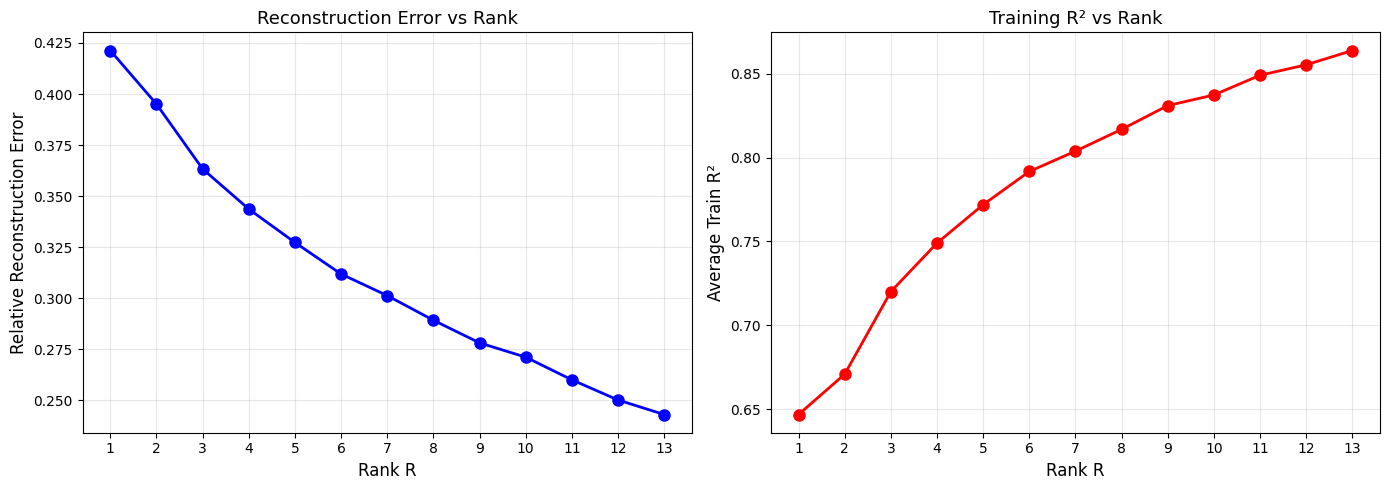


Suggested rank (elbow): 4
Max rank (before over-parameterization): 13


In [80]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

valid_ranks = [r for r, e in zip(ranks, reconstruction_errors) if not np.isnan(e)]
valid_errors = [e for e in reconstruction_errors if not np.isnan(e)]
valid_r2 = [r for r in train_r2_scores if not np.isnan(r)]

ax1.plot(valid_ranks, valid_errors, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Rank R', fontsize=12)
ax1.set_ylabel('Relative Reconstruction Error', fontsize=12)
ax1.set_title('Reconstruction Error vs Rank', fontsize=13)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(valid_ranks)

ax2.plot(valid_ranks, valid_r2, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Rank R', fontsize=12)
ax2.set_ylabel('Average Train R²', fontsize=12)
ax2.set_title('Training R² vs Rank', fontsize=13)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(valid_ranks)

plt.tight_layout()
plt.show()

# Find elbow point (where error reduction slows down)
if len(valid_errors) >= 3:
    error_diffs = np.diff(valid_errors)
    error_diffs2 = np.diff(error_diffs)
    elbow_rank = valid_ranks[np.argmax(error_diffs2) + 2]
else:
    elbow_rank = 2
print(f"\nSuggested rank (elbow): {elbow_rank}")
print(f"Max rank (before over-parameterization): {max_rank}")

## 3. Forecasting Across Ranks

For each rank, decompose → forecast → measure test R². This shows how decomposition quality affects forecasting.

In [81]:
def forecast_with_rank(train_tensor, test_tensor, R, ar_lags=1):
    """Decompose, forecast day factors, reconstruct forecast tensor."""
    weights, factors = parafac(train_tensor, rank=R, normalize_factors=True)
    day_factors, time_factors, feature_factors = factors
    
    # Forecast day factors using AutoReg
    forecast_day_factors = np.zeros((TEST_DAYS, R))
    for r in range(R):
        series = day_factors[:, r]
        model = AutoReg(series, lags=ar_lags, old_names=False)
        model_fit = model.fit()
        forecast = model_fit.forecast(steps=TEST_DAYS)
        forecast_day_factors[:, r] = forecast
    
    # Reconstruct forecast tensor
    forecast_tensor = np.zeros((TEST_DAYS, TIME, FEATURES))
    for i in range(TEST_DAYS):
        for r in range(R):
            forecast_tensor[i, :, :] += weights[r] * np.outer(
                forecast_day_factors[i, r] * time_factors[:, r], 
                feature_factors[:, r]
            )
    
    return forecast_tensor

In [82]:
test_r2_by_rank = []
test_rmse_by_rank = []

for R in ranks:
    try:
        forecast_tensor = forecast_with_rank(train_tensor, test_tensor, R)
        
        test_series = test_tensor.reshape(-1, FEATURES)
        forecast_series = forecast_tensor.reshape(-1, FEATURES)
        
        r2_vals = []
        rmse_vals = []
        for f in range(FEATURES):
            r2_vals.append(r2_score(test_series[:, f], forecast_series[:, f]))
            rmse_vals.append(root_mean_squared_error(test_series[:, f], forecast_series[:, f]))
        
        test_r2_by_rank.append(np.mean(r2_vals))
        test_rmse_by_rank.append(np.mean(rmse_vals))
    except Exception as e:
        print(f"Rank {R} forecast failed: {e}")
        test_r2_by_rank.append(np.nan)
        test_rmse_by_rank.append(np.nan)

print("Rank | Test R²  | Test RMSE")
print("-" * 35)
for R, r2, rmse in zip(ranks, test_r2_by_rank, test_rmse_by_rank):
    print(f"  {R:2d}  |  {r2:.4f}  |  {rmse:.4f}")

valid_r2 = [(r, v) for r, v in zip(ranks, test_r2_by_rank) if not np.isnan(v)]
best_rank = max(valid_r2, key=lambda x: x[1])[0] if valid_r2 else 2
print(f"\nBest rank by test R²: {best_rank}")

Rank | Test R²  | Test RMSE
-----------------------------------
   1  |  0.6033  |  27.7878
   2  |  0.5907  |  28.1243
   3  |  0.6062  |  27.7989
   4  |  0.6021  |  27.8300
   5  |  0.6027  |  27.8696
   6  |  0.5957  |  28.0508
   7  |  0.6026  |  27.8891
   8  |  0.5947  |  28.1613
   9  |  0.5784  |  28.7562
  10  |  0.6022  |  27.9255
  11  |  0.6052  |  27.8400
  12  |  0.5935  |  28.1822
  13  |  0.6073  |  27.7382

Best rank by test R²: 13


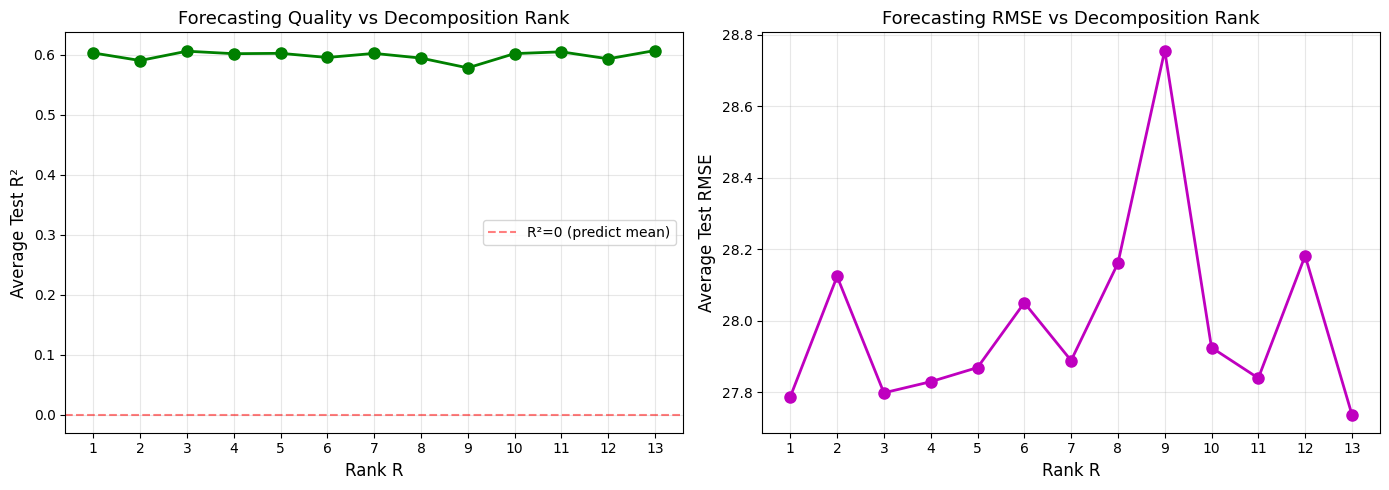

In [83]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

valid_ranks = [r for r, v in zip(ranks, test_r2_by_rank) if not np.isnan(v)]
valid_test_r2 = [v for v in test_r2_by_rank if not np.isnan(v)]
valid_test_rmse = [v for v in test_rmse_by_rank if not np.isnan(v)]

ax1.plot(valid_ranks, valid_test_r2, 'go-', linewidth=2, markersize=8)
ax1.set_xlabel('Rank R', fontsize=12)
ax1.set_ylabel('Average Test R²', fontsize=12)
ax1.set_title('Forecasting Quality vs Decomposition Rank', fontsize=13)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(valid_ranks)
ax1.axhline(y=0, color='r', linestyle='--', alpha=0.5, label='R²=0 (predict mean)')
ax1.legend()

ax2.plot(valid_ranks, valid_test_rmse, 'mo-', linewidth=2, markersize=8)
ax2.set_xlabel('Rank R', fontsize=12)
ax2.set_ylabel('Average Test RMSE', fontsize=12)
ax2.set_title('Forecasting RMSE vs Decomposition Rank', fontsize=13)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(valid_ranks)

plt.tight_layout()
plt.show()

## 4. Detailed Analysis with Best Rank

In [84]:
R = best_rank
print(f"Using rank R = {R}")

weights, factors = parafac(train_tensor, rank=R, normalize_factors=True)
day_factors, time_factors, feature_factors = factors

reconstructed_tensor = cp_to_tensor((weights, factors))

# Reconstruction error analysis
rel_error = np.linalg.norm(train_tensor - reconstructed_tensor) / np.linalg.norm(train_tensor)
print(f"Relative reconstruction error: {rel_error:.6f}")

# Per-feature reconstruction R²
print("\nPer-feature reconstruction R²:")
for f in range(FEATURES):
    r2 = r2_score(train_tensor[:, :, f].flatten(), reconstructed_tensor[:, :, f].flatten())
    print(f"  Feature {f}: R² = {r2:.6f}")

Using rank R = 13
Relative reconstruction error: 0.243097

Per-feature reconstruction R²:
  Feature 0: R² = 0.853192
  Feature 1: R² = 0.908577
  Feature 2: R² = 0.857179
  Feature 3: R² = 0.934665
  Feature 4: R² = 0.853635
  Feature 5: R² = 0.811041
  Feature 6: R² = 0.838637
  Feature 7: R² = 0.887950
  Feature 8: R² = 0.811855
  Feature 9: R² = 0.875303
  Feature 10: R² = 0.854575
  Feature 11: R² = 0.799291
  Feature 12: R² = 0.943860


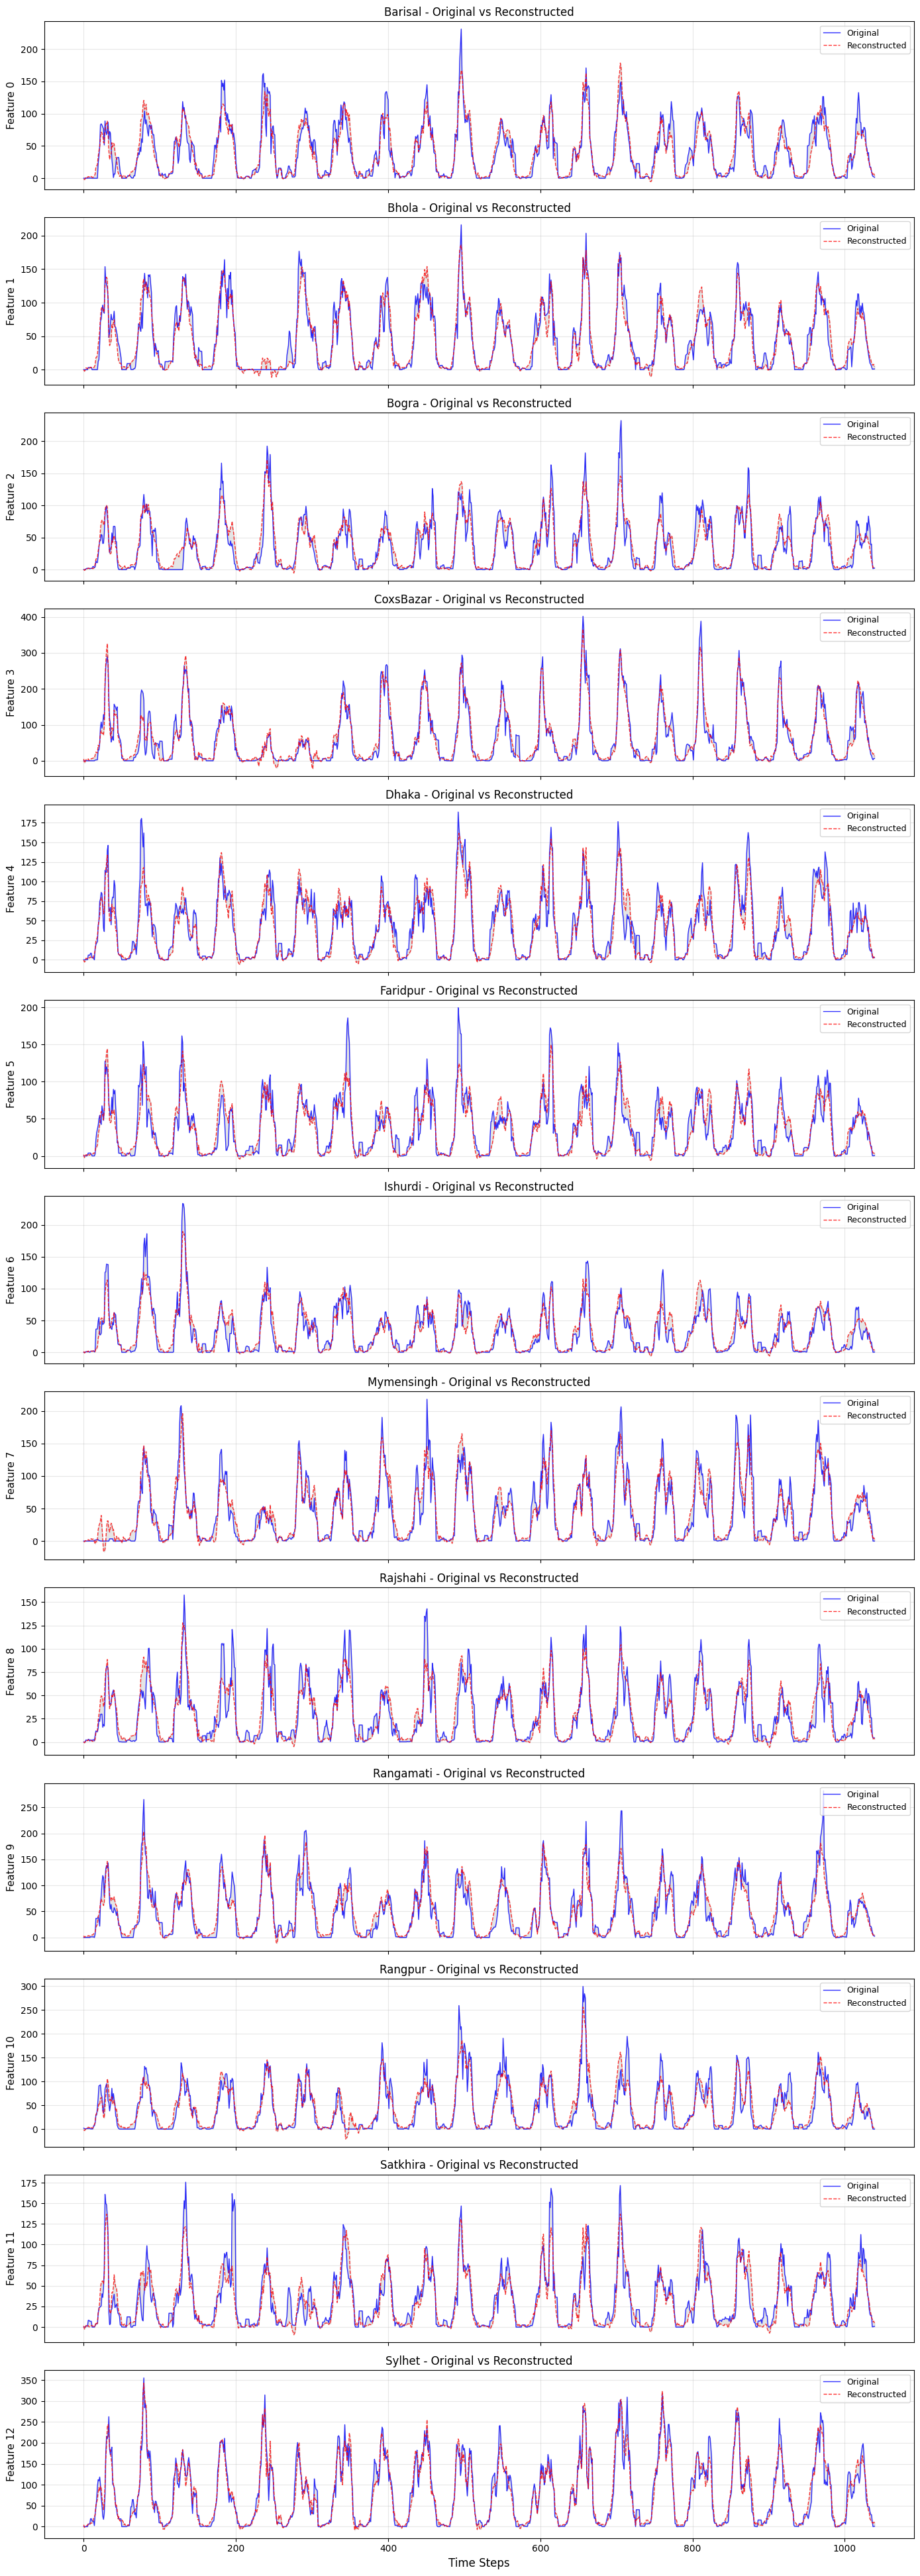

In [85]:
# Visualize reconstruction quality for each feature
feature_names = numeric_cols.tolist()
if len(feature_names) != FEATURES:
    raise ValueError(
        f"FEATURES={FEATURES}, but the input data has {len(feature_names)} numeric features."
    )

fig, axes = plt.subplots(FEATURES, 1, figsize=(14, 3*FEATURES), sharex=True)
if FEATURES == 1:
    axes = [axes]

for f in range(FEATURES):
    ax = axes[f]
    original = train_tensor[:, :, f].flatten()
    recon = reconstructed_tensor[:, :, f].flatten()
    
    ax.plot(original, 'b-', lw=1, label='Original', alpha=0.8)
    ax.plot(recon, 'r--', lw=1, label='Reconstructed', alpha=0.8)
    ax.fill_between(range(len(original)), original, recon, alpha=0.2, color='gray')
    ax.set_ylabel(f'Feature {f}', fontsize=11)
    ax.set_title(f'{feature_names[f]} - Original vs Reconstructed', fontsize=12)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.xlabel('Time Steps', fontsize=12)
plt.tight_layout()
plt.show()

## 5. Final Forecast with Best Rank

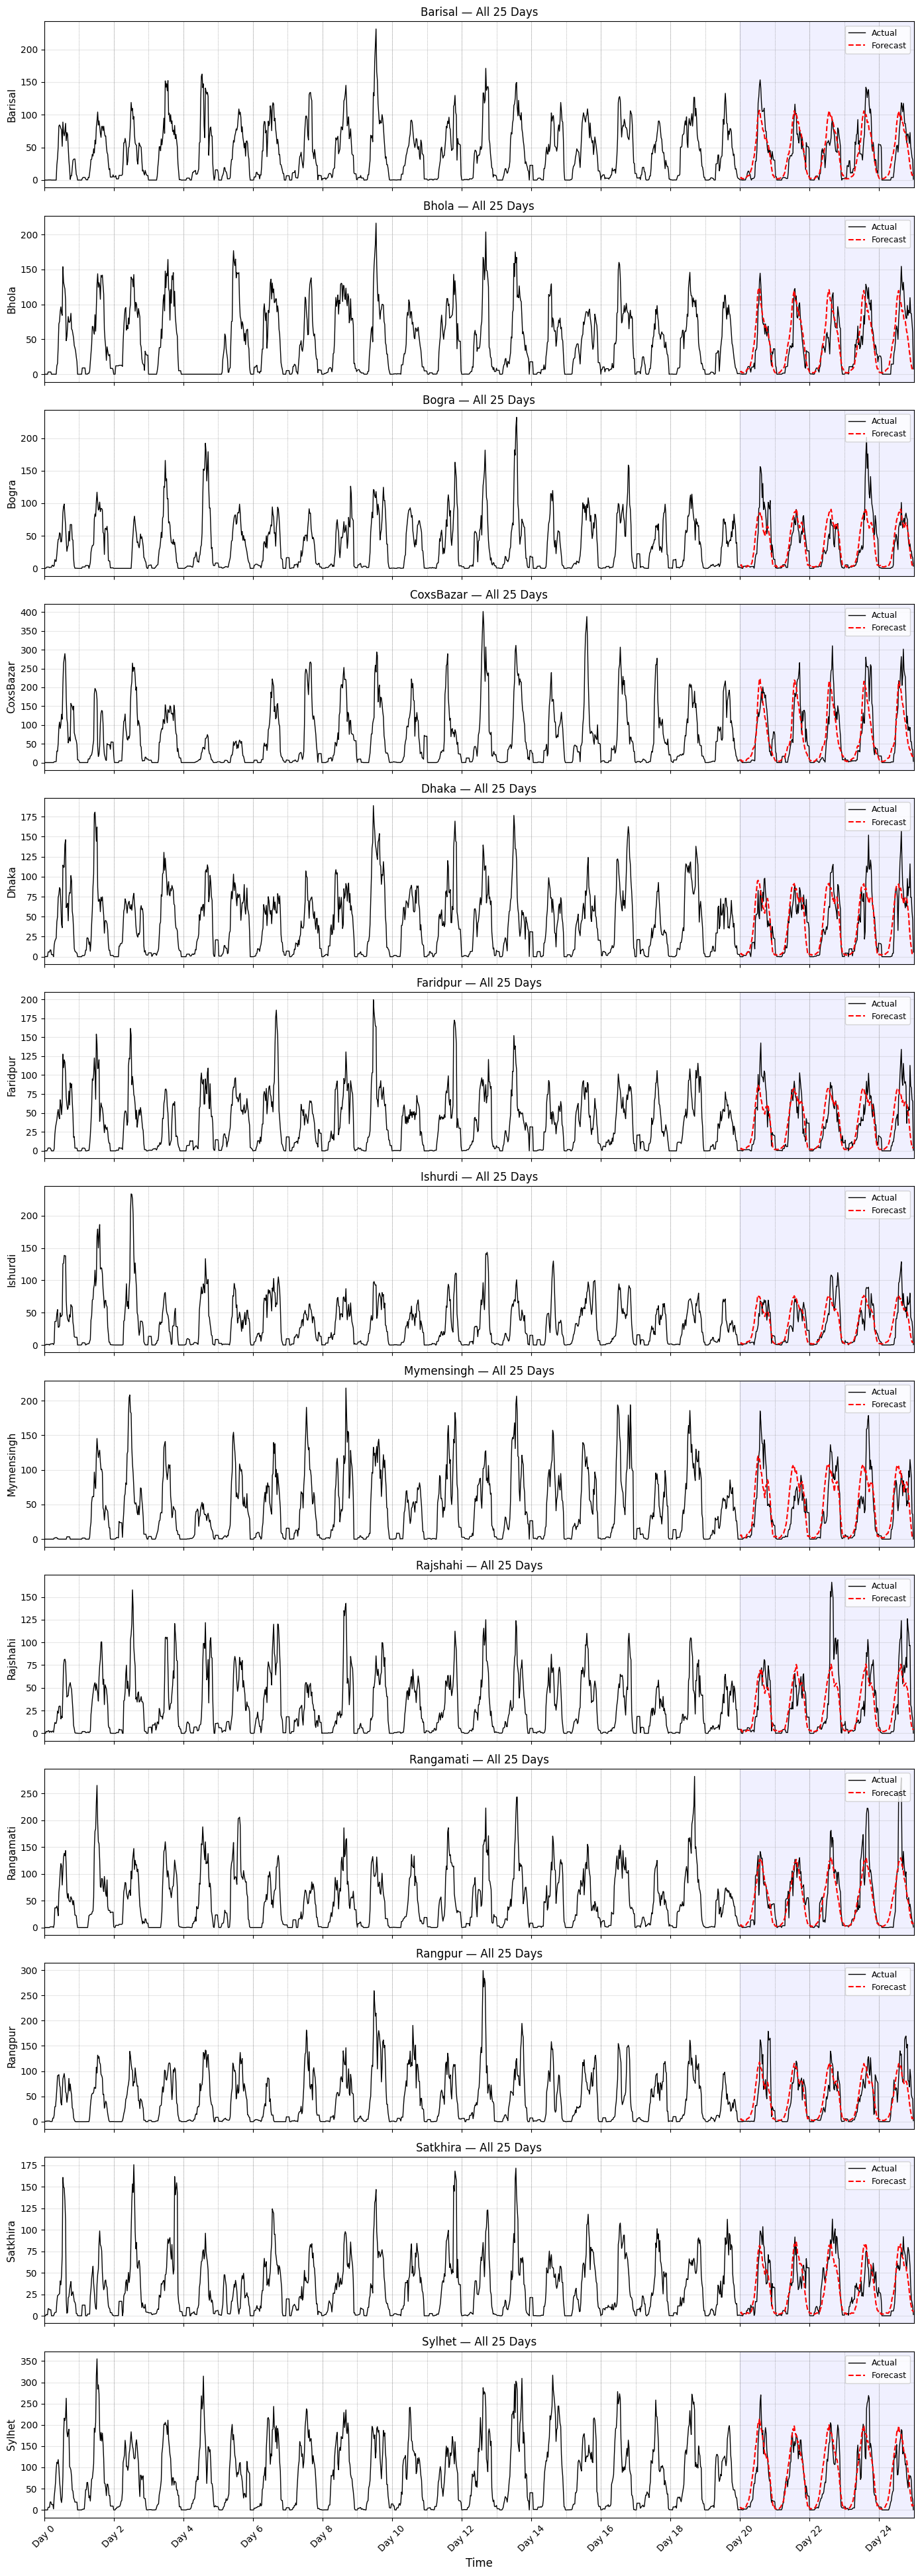

In [86]:
forecast_tensor = forecast_with_rank(train_tensor, test_tensor, R)

# Visualization: all days
full_series = tensor.reshape(-1, FEATURES)
forecast_series = forecast_tensor.reshape(-1, FEATURES)

T = PERIOD * TIME
x = np.arange(T)
forecast_start = TRAIN_DAYS * TIME
x_forecast = np.arange(forecast_start, forecast_start + TEST_DAYS * TIME)

fig, axes = plt.subplots(FEATURES, 1, figsize=(14, 3*FEATURES), sharex=True)
if FEATURES == 1:
    axes = [axes]

for i in range(FEATURES):
    ax = axes[i]
    ax.plot(x, full_series[:, i], 'k-', lw=1, label='Actual')
    ax.plot(x_forecast, forecast_series[:, i], 'r--', lw=1.5, label='Forecast')
    for d in range(1, PERIOD + 1):
        ax.axvline(d * TIME, color='gray', ls=':', lw=0.5)
    ax.axvspan(forecast_start, T, alpha=0.06, color='blue')
    ax.set_ylabel(f'{feature_names[i]}', fontsize=11)
    ax.set_title(f'{feature_names[i]} — All {PERIOD} Days', fontsize=12)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.xticks(np.arange(0, T + 1, 2 * TIME),
           [f'Day {d}' for d in range(0, PERIOD + 1, 2)], rotation=45)
plt.xlim(0, T)
plt.xlabel('Time', fontsize=12)
plt.tight_layout()
plt.show()

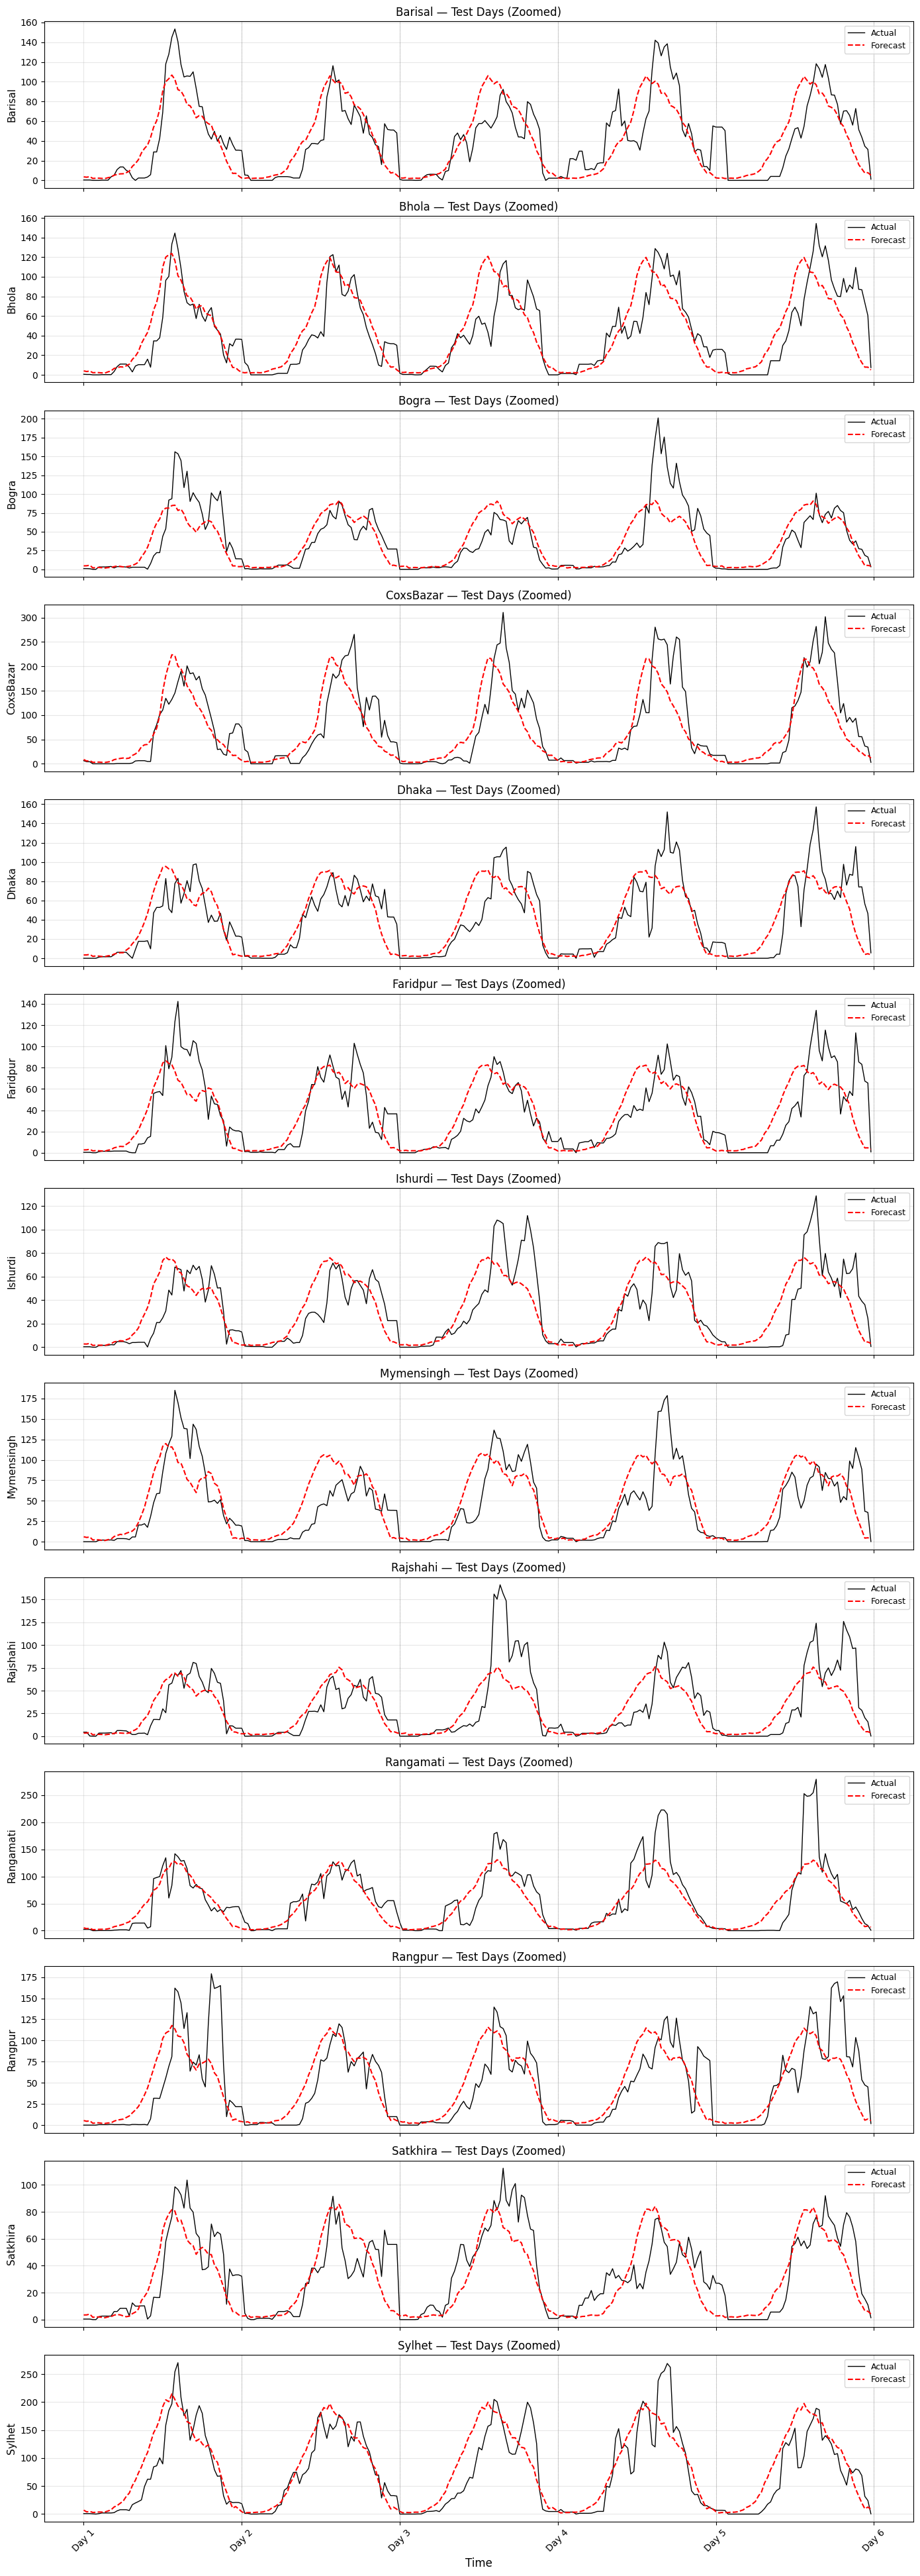

In [87]:
# Zoomed view: test days only
test_series = test_tensor.reshape(-1, FEATURES)
forecast_series = forecast_tensor.reshape(-1, FEATURES)
x = np.arange(TEST_DAYS * TIME)

fig, axes = plt.subplots(FEATURES, 1, figsize=(14, 3*FEATURES), sharex=True)
if FEATURES == 1:
    axes = [axes]

for i in range(FEATURES):
    ax = axes[i]
    ax.plot(x, test_series[:, i], 'k-', lw=1, label='Actual')
    ax.plot(x, forecast_series[:, i], 'r--', lw=1.5, label='Forecast')
    for d in range(1, TEST_DAYS + 1):
        ax.axvline(d * TIME, color='gray', ls=':', lw=0.5)
    ax.set_ylabel(f'{feature_names[i]}', fontsize=11)
    ax.set_title(f'{feature_names[i]} — Test Days (Zoomed)', fontsize=12)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.xticks(np.arange(0, TEST_DAYS * TIME + 1, TIME),
           [f'Day {d}' for d in range(1, TEST_DAYS + 2)], rotation=45)
plt.xlabel('Time', fontsize=12)
plt.tight_layout()
plt.show()

## 6. Final Evaluation Metrics

In [88]:
print(f"Final model: Rank R = {R}")
print(f"Relative reconstruction error: {rel_error:.6f}")
print()

r2_scores = []
mse_scores = []
mae_scores = []
rmse_scores = []

for i in range(FEATURES):
    r2 = r2_score(test_series[:, i], forecast_series[:, i])
    mse = mean_squared_error(test_series[:, i], forecast_series[:, i])
    mae = mean_absolute_error(test_series[:, i], forecast_series[:, i])
    rmse = root_mean_squared_error(test_series[:, i], forecast_series[:, i])
    r2_scores.append(r2)
    mse_scores.append(mse)
    mae_scores.append(mae)
    rmse_scores.append(rmse)
    print(f"Feature {i} ({feature_names[i]:15s}): R²={r2:.4f}, RMSE={rmse:.4f}, MAE={mae:.4f}")

print()
print(f"Average:          R²={np.mean(r2_scores):.4f}, RMSE={np.mean(rmse_scores):.4f}, MAE={np.mean(mae_scores):.4f}")

Final model: Rank R = 13
Relative reconstruction error: 0.243097

Feature 0 (Barisal        ): R²=0.5939, RMSE=24.2186, MAE=18.5108
Feature 1 (Bhola          ): R²=0.5820, RMSE=25.4210, MAE=18.0693
Feature 2 (Bogra          ): R²=0.6043, RMSE=25.4136, MAE=16.7037
Feature 3 (CoxsBazar      ): R²=0.6726, RMSE=47.3723, MAE=33.3198
Feature 4 (Dhaka          ): R²=0.5890, RMSE=23.6689, MAE=16.5827
Feature 5 (Faridpur       ): R²=0.5796, RMSE=22.0963, MAE=15.5512
Feature 6 (Ishurdi        ): R²=0.5632, RMSE=20.4962, MAE=14.5518
Feature 7 (Mymensingh     ): R²=0.5435, RMSE=29.8985, MAE=20.8986
Feature 8 (Rajshahi       ): R²=0.5698, RMSE=23.7577, MAE=15.7043
Feature 9 (Rangamati      ): R²=0.7021, RMSE=32.2074, MAE=20.4700
Feature 10 (Rangpur        ): R²=0.5790, RMSE=30.5878, MAE=20.9224
Feature 11 (Satkhira       ): R²=0.5782, RMSE=18.9831, MAE=14.0693
Feature 12 (Sylhet         ): R²=0.7381, RMSE=36.4756, MAE=25.4381

Average:          R²=0.6073, RMSE=27.7382, MAE=19.2917
